# NB4: Statistical Downscaling of Global Climate Models using climate4R

## 1. Introduction
Global Climate Models (GCMs) are the primary tools used to simulate future climate under different greenhouse gas emission scenarios. Although they provide physically consistent representations of the Earth's climate system, their relatively coarse spatial resolution often limits their direct applicability to regional and local climate impact studies.

Statistical downscaling (SD) addresses this limitation by establishing empirical/statistical relationships between large-scale atmospheric variables simulated by GCMs (predictors) and local-scale observations (predictands). Once calibrated during a historical reference period, these relationships can be applied to future GCM predictors to generate climate projections with a spatial resolution and statistical behaviour that are more suitable for regional applications.

In this notebook, we explore the SD workflow implemented in the `downscaleR` package, which relies on the Perfecto Prognosis (PP) approach: Starting from "perfect" predictor (ERA5) and predictand (local observations) data, we calibrate the statistical downscaling model, validate its performance over a historical reference period, and finally apply it to "imperfect" GCM predictors to obtain the corresponding downscaled projections. 

Because statistical downscaling relies on observational records to calibrate the predictors-predictand statistical relationships, future projections can only be generated for locations where suitable observations are available. Therefore, unlike the previous notebook, which focused on bias adjustment of regional climate model (RCM) simulations, the analyses presented in this notebook will produce future projections for individual meteorological stations rather than spatially continuous fields.

### 1.1. Learning Objectives
After completing this notebook, you should be able to

* understand the purpose and limitations of statistical downscaling;
* calibrate statistical downscaling models using historical observations and large-scale predictors;
* validate the performance of the calibrated models;
* apply statistical downscaling models to future GCM projections;
* compare raw and downscaled climate simulations at local and regional scales.

## 2. Preparing the Working Environment
First, it is necessary to define a few parameters controlling the analysis to be undertaken and load the required libraries.

The climate4R ecosystem provides a collection of packages specifically designed for handling climate data. These packages  (`loadeR`, `transformeR`, `visualizeR`, `downscaleR`, `climate4R.value`) allow users to manipulate both station observations and gridded datasets through a common data structure, making subsequent analyses considerably easier (including temporal and spatial subsetting, regridding, visualization, bias correction and statistical downscaling).

In addition, some extra libraries outside climate4R (`RColorBrewer`, `lattice`, `gridExtra`) are also loaded to facilitate the production of publication-quality figures.

In [1]:
rm(list = ls())

## params ##
dirbase = "/home/jovyan"
dirdata.obs = sprintf("%s/data/obs", dirbase)
dirdata.era5 = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/era5_interp25"  # ERA5, already interpolated to a regular 2.5º grid
dirdata.cmip5 = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/cmip5" 

lon = c(66, 75)
lat = c(24, 35)

#lon = c(70, 74)
#lat = c(26, 33)

## libraries ##
library(loadeR)
library(transformeR)
library(visualizeR)
library(downscaleR)
library(climate4R.value)
library(RColorBrewer)
library(lattice)
library(gridExtra)

## auxiliary functions ##
source(sprintf("%s/notebooks/auxiliary_functions.R", dirbase))

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 2.00 GB

NetCDF Java Library Version: 5.10.0 (Built-On: NA) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from env LOADER_JAVA_CLASSPATH + bundled java package directory: /home/rodri/miniforge3/envs/C4R-pakistan/lib/java/toolsUI.jar:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

downscaleR version 3.3.4 (2023-06-22) is loaded

Please use 'citation("downscaleR")' to cite this package.

Loading required package: VALUE

---------------------------------------------- 
| VALUE version 2.2.4 (2023-06-22) is loaded |
|         http://www.value-cost.eu           |
----------------------------------------------



## 3. Loading Observed Predictand and ERA5 Predictors

The first step in any statistical downscaling exercise is to prepare both the predictand (the local variable to be downscaled) and the predictors (the large-scale atmospheric variables used to explain its variability).

In this notebook, the predictand is the daily maximum temperature measured at meteorological stations across Pakistan. As per the predictors chosen, we stick to the Perfect Prognosis approach for statistical downscaliang (PP-SD); therefore:

* for the calibration phase, ERA5 predictors must be used;
* only atmospheric variables which are well reproduced by GCMs (e.g. geopotential height, winds) and carry the climate change signal (e.g. humidity) should be used.

With this in mind, the set of predictors considered for this notebook includes geopotential height at 850 hPa and 500 hPa (z850 and z500), air temperature at 850 hPa (t850), zonal wind at 850 hPa (u850), and specific humidity at 850 hPa (q850). Together, these variables describe the large-scale atmospheric circulation and thermodynamic conditions that influence local temperature.

Since the predictors originate from different datasets, they are first interpolated onto a common 2.5º x 2.5º regular grid and combined into a single multi-variable object (function `makeMultiGrid()` from `transformeR`). The observational and reanalysis datasets are then temporally aligned by extracting their common period (1997-2016).

Finally, climatological maps of the ERA5 predictors are displayed. These maps provide an overview of the spatial structure of each atmospheric variable and help to familiarise with the large-scale circulation patterns that will be used to train the statistical downscaling models.

In [2]:
## loading observed predictand ##
y = "tmax"
load(sprintf("%s/%s.rda", dirdata.obs, y)) 
y.obs = data; rm(data)
getShape(y.obs)
range(y.obs$Dates$start)

time  loc 
7295   14

[1] "1997-01-01 00:00:00" "2016-12-31 00:00:00"

In [3]:
## loading ERA5 predictors ##
#x = c("z850", "z500", "t850", "u850", "q850")  # set of predictor variables considered
x = c("z850", "t850") # set of predictor variables considered

## looping over predictors ##
x.era5 = lapply(x, function(ivar) {
  print(sprintf("... loading and interpolating %s for ERA5 ...", ivar))
  
  # loading predictor data ##
  data = loadGridData(sprintf("%s/%s.nc", dirdata.era5, ivar),
                     var = ivar, lonLim = lon, latLim = lat,
                     years = 1997:2016) 
  return(data)
})

x.era5 = makeMultiGrid(x.era5)  # binding all predictor variables into a single C4R object

[1] "... loading and interpolating z850 for ERA5 ..."


[2026-07-17 18:52:12.753365] Opening dataset...

[2026-07-17 18:52:13.962522] The dataset was successfuly opened

[2026-07-17 18:52:13.968375] Defining geo-location parameters

[2026-07-17 18:52:14.058007] Defining time selection parameters

[2026-07-17 18:52:14.215096] Retrieving data subset ...

[2026-07-17 18:52:16.227442] Done



[1] "... loading and interpolating t850 for ERA5 ..."


[2026-07-17 18:52:16.4563] Opening dataset...

[2026-07-17 18:52:16.927489] The dataset was successfuly opened

[2026-07-17 18:52:16.932885] Defining geo-location parameters

[2026-07-17 18:52:16.966892] Defining time selection parameters

[2026-07-17 18:52:17.069615] Retrieving data subset ...

[2026-07-17 18:52:19.027304] Done



In [4]:
getShape(x.era5)
x.era5 = redim(x.era5, drop = TRUE)
getShape(x.era5)
range(x.era5$Dates)

var member   time    lat    lon 
     2      1   7305      5      5

var time  lat  lon 
   2 7305    5    5

[1] "1997-01-01 00:00:00 GMT" "2016-12-31 00:00:00 GMT"

In [5]:
## extracting common period to observations and ERA5 (1997-2016) ##
x.era5 = intersectGrid(x.era5, y.obs, type = "temporal", which.return = 1)  ## the dates for the predictand and the predictors must be exactly the same for the calibration phase

y.obs$Dates$start = x.era5$Dates[[1]]$start  # harmonizing predictors and predictand dates
y.obs$Dates$end = x.era5$Dates[[1]]$end  # harmonizing predictors and predictand dates

[2026-07-17 18:52:19.466578] - Computing climatology...

[2026-07-17 18:52:19.469652] - Done.

[2026-07-17 18:52:19.5126] - Computing climatology...

[2026-07-17 18:52:19.523427] - Done.



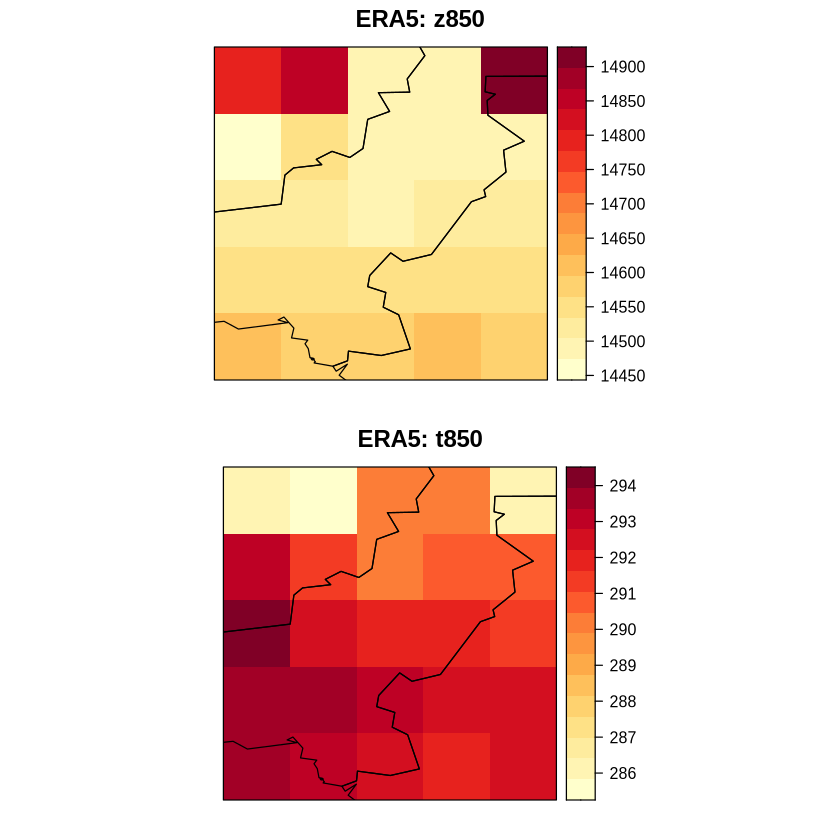

In [6]:
## plotting ERA5 predictor's climatologies ##
clim.x.era5 = lapply(1:getShape(x.era5)["var"], function(ivar) {
  x.era5.var = subsetDimension(x.era5, dimension = "var", indices = ivar)
  spatialPlot(climatology(x.era5.var), backdrop.theme = "countries",
              color.theme = "YlOrRd",
              main = sprintf("ERA5: %s", x[ivar]))
})
grid.arrange(grobs = clim.x.era5)

## 4. Calibration of the Statistical Downscaling Models (in Cross-Validation Mode)

Before applying a statistical downscaling model to future climate projections, it is essential to evaluate its ability to reproduce the observed climate under present-day conditions. In this section, two widely used statistical downscaling techniques are assessed using cross-validation, providing an objective estimate of their performance.

The first method is the Analogs approach, which predicts the local predictand based on the historical large-scale atmospheric situations that are most similar to the target day. The second method is Multiple Linear Regression (MLR), implemented through a Generalized Linear Model (GLM) with a Gaussian response, which establishes an explicit statistical relationship between the large-scale atmospheric predictors and the observed predictand.

Both methods are evaluated using a two-fold chronological cross-validation strategy. Unlike random cross-validation, chronological sampling preserves the temporal ordering of the data, ensuring that each validation subset consists of continuous periods that are excluded from the calibration process. This provides a more realistic assessment of model performance for climate applications, where temporal dependence is an important consideration.

Prior to model calibration, all predictor variables are standardised to remove differences in scale, and a Principal Component Analysis (PCA) is applied to the spatial predictor fields. Rather than using every grid point directly, the leading principal components explaining 80% of the total variance are considered. This dimensionality reduction decreases computational cost, removes redundancy among predictors and helps produce more robust statistical models.

The cross-validated predictions generated by both methods will be analysed in the following sections to compare their ability to reproduce the observed daily maximum temperatures and to identify the most suitable downscaling technique for subsequent climate projections.

In [7]:
## analogs ##
y.pred.ana = downscaleCV(x.era5, y.obs, 
                     method = "analogs", 
                     folds = 2, 
                     sampling.strategy = "kfold.chronological",
                     scaleGrid.args = list(type = "standardize"),
                     prepareData.args = list("spatial.predictors" = list(which.combine = getVarNames(x.era5), v.exp = 0.8)))
getShape(y.pred.ana)

fold: 1 --> calculating...

[2026-07-17 18:52:23.804181] - Scaling ...

[2026-07-17 18:52:24.181995] - Done

[2026-07-17 18:52:24.183691] - Scaling ...

[2026-07-17 18:52:24.305408] - Done

[2026-07-17 18:52:24.37121] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:52:24.432263] Done.

fold: 2 --> calculating...

[2026-07-17 18:52:29.876922] - Scaling ...

[2026-07-17 18:52:29.998257] - Done

[2026-07-17 18:52:29.99997] - Scaling ...

[2026-07-17 18:52:30.10132] - Done

[2026-07-17 18:52:30.178805] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:52:30.218592] Done.



time  loc 
7295   14

In [8]:
## multiple linear regression ##
y.pred.mlr = downscaleCV(x.era5, y.obs,  
                     method = "GLM", family = gaussian(link = "identity"),
                     folds = 2,
                     sampling.strategy = "kfold.chronological",
                     scaleGrid.args = list(type = "standardize"),
                     prepareData.args = list("spatial.predictors" = list(which.combine = getVarNames(x.era5), v.exp = 0.8)))
getShape(y.pred.mlr)

fold: 1 --> calculating...

[2026-07-17 18:52:34.722999] - Scaling ...

[2026-07-17 18:52:34.83569] - Done

[2026-07-17 18:52:34.837354] - Scaling ...

[2026-07-17 18:52:34.953435] - Done

[2026-07-17 18:52:35.012637] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:52:35.039459] Done.

fold: 2 --> calculating...

[2026-07-17 18:52:35.113336] - Scaling ...

[2026-07-17 18:52:35.227893] - Done

[2026-07-17 18:52:35.229591] - Scaling ...

[2026-07-17 18:52:35.348254] - Done

[2026-07-17 18:52:35.404954] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:52:35.455386] Done.



time  loc 
7295   14

## 5. Validation of the Statistical Downscaling Models (in Cross-Validation Mode) 
The cross-validated predictions obtained with the Analogs and Multiple Linear Regression (MLR) methods are now compared with the observed climatology of daily maximum temperature. For each dataset, the long-term climatological mean is calculated and represented as a spatial map over the network of meteorological stations.

Displaying the observed and predicted climatologies side by side provides a first qualitative assessment of the performance of the two statistical downscaling methods. A successful downscaling model should reproduce the main spatial gradients, capturing the differences between cooler mountainous regions and the warmer lowlands while remaining consistent with the observed station climatology.

[2026-07-17 18:52:35.568374] - Computing climatology...

[2026-07-17 18:52:35.570398] - Done.

[2026-07-17 18:52:35.574371] - Computing climatology...

[2026-07-17 18:52:35.576091] - Done.

[2026-07-17 18:52:35.579509] - Computing climatology...

[2026-07-17 18:52:35.581607] - Done.



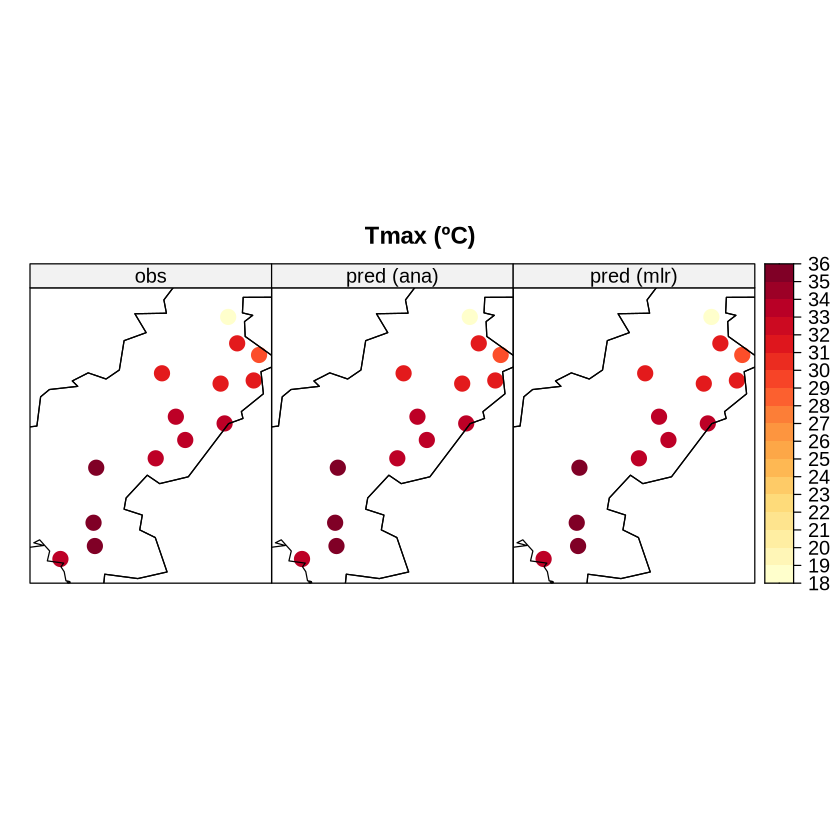

In [9]:
## plotting the predictions ##
cols = brewer.pal(9, "YlOrRd")
cb.bins = seq(18, 36, 1)
spatialPlot(makeMultiGrid(climatology(y.obs), 
                          climatology(y.pred.ana),
                          climatology(y.pred.mlr)), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Tmax (ºC)",
            names.attr = c("obs", "pred (ana)", "pred (mlr)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

The next step is to assess how well the statistical downscaling models reproduce the observed climate beyond a simple climatological map. No single performance metric can fully characterise model skill, so three complementary diagnostics are considered: bias, daily correlation and interannual correlation.

The first diagnostic is the mean bias, computed as the difference between the climatological mean of the predictions and that of the observations. This metric quantifies systematic overestimation or underestimation of maximum temperature at each station and provides a straightforward measure of the models' ability to reproduce the observed mean climate.

The second diagnostic evaluates the daily Pearson correlation coefficient between the observed and predicted time series. This measure assesses how well each downscaling method captures the day-to-day variability of maximum temperature, indicating its ability to reproduce individual weather fluctuations rather than only long-term averages.

Finally, we also assess interannual correlation. This metric focuses on lower-frequency climate variability, evaluating whether the downscaling models correctly reproduce year-to-year fluctuations. Capturing this variability is particularly important for climate monitoring and climate change applications.

Together, these three diagnostics provide a comprehensive assessment of model performance by evaluating different temporal scales and complementary aspects of the downscaled climate. Comparing the Analogs and Multiple Linear Regression (MLR) methods across all metrics helps identify their respective strengths and limitations before applying them to future GCM projections.

[2026-07-17 18:52:41.233304] - Computing climatology...

[2026-07-17 18:52:41.235705] - Done.

[2026-07-17 18:52:41.239925] - Computing climatology...

[2026-07-17 18:52:41.241934] - Done.

[2026-07-17 18:52:41.247421] - Computing climatology...

[2026-07-17 18:52:41.249431] - Done.

[2026-07-17 18:52:41.252939] - Computing climatology...

[2026-07-17 18:52:41.25462] - Done.



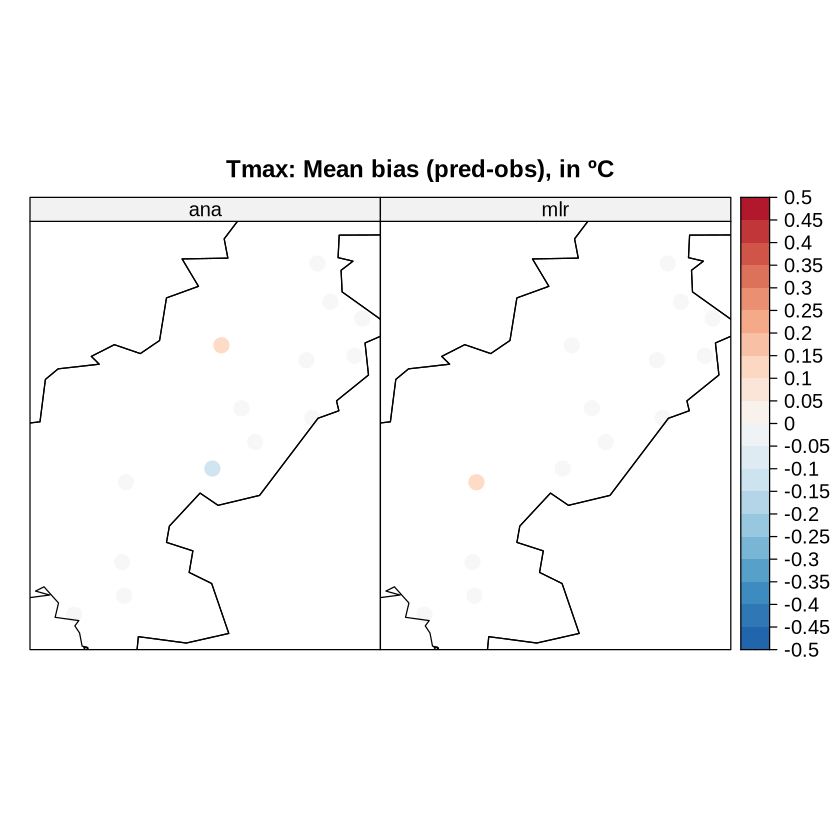

In [10]:
## mean bias ##
bias.ana = gridArithmetics(climatology(y.pred.ana), 
                                  climatology(y.obs), operator = "-")
bias.mlr = gridArithmetics(climatology(y.pred.mlr), 
                                    climatology(y.obs), operator = "-")
cols = rev(brewer.pal(9, "RdBu"))
cb.bins = seq(-0.5, 0.5, 0.05)
spatialPlot(makeMultiGrid(bias.ana, bias.mlr), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Tmax: Mean bias (pred-obs), in ºC",
            names.attr = c("ana", "mlr"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

[2026-07-17 18:52:44.525858] Computing member 1 out of 1

[2026-07-17 18:52:44.546685] Done.

[2026-07-17 18:52:44.55529] Computing member 1 out of 1

[2026-07-17 18:52:44.578407] Done.



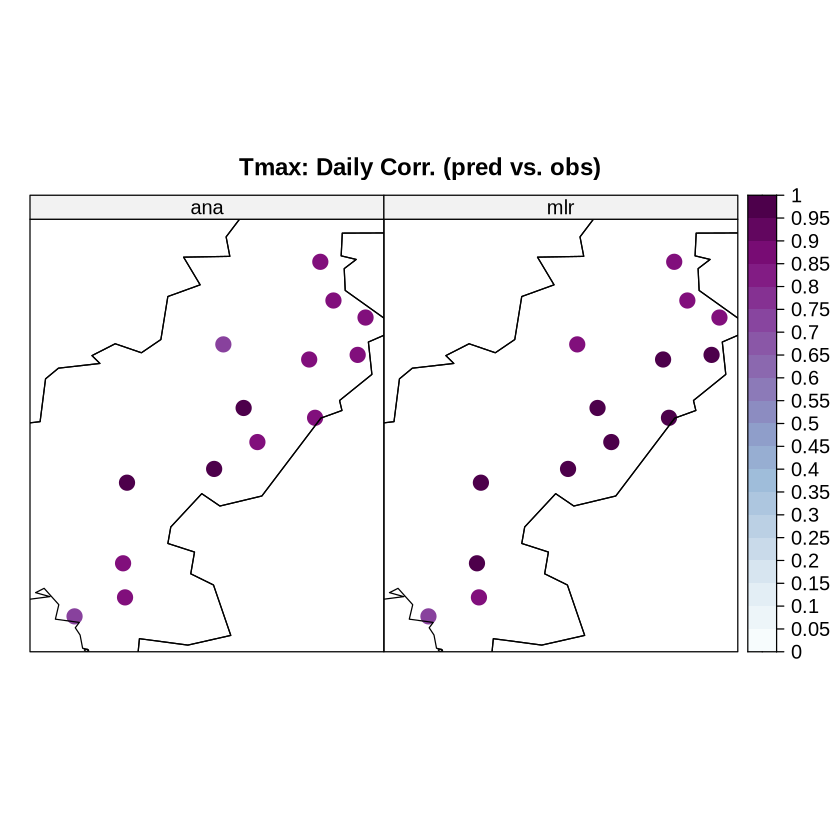

In [11]:
## daily correlation ##
rho.ana = valueMeasure(y.obs, y.pred.ana, measure.code = "ts.rp")
rho.mlr = valueMeasure(y.obs, y.pred.mlr, measure.code = "ts.rp")
cols = brewer.pal(9, "BuPu")
cb.bins = seq(0, 1, 0.05)
spatialPlot(makeMultiGrid(rho.ana$Measure, rho.mlr$Measure),
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Tmax: Daily Corr. (pred vs. obs)",
            names.attr = c("ana", "mlr"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

[2026-07-17 18:52:48.26804] Computing member 1 out of 1

[2026-07-17 18:52:48.299504] Done.

[2026-07-17 18:52:48.307515] Computing member 1 out of 1

[2026-07-17 18:52:48.341328] Done.



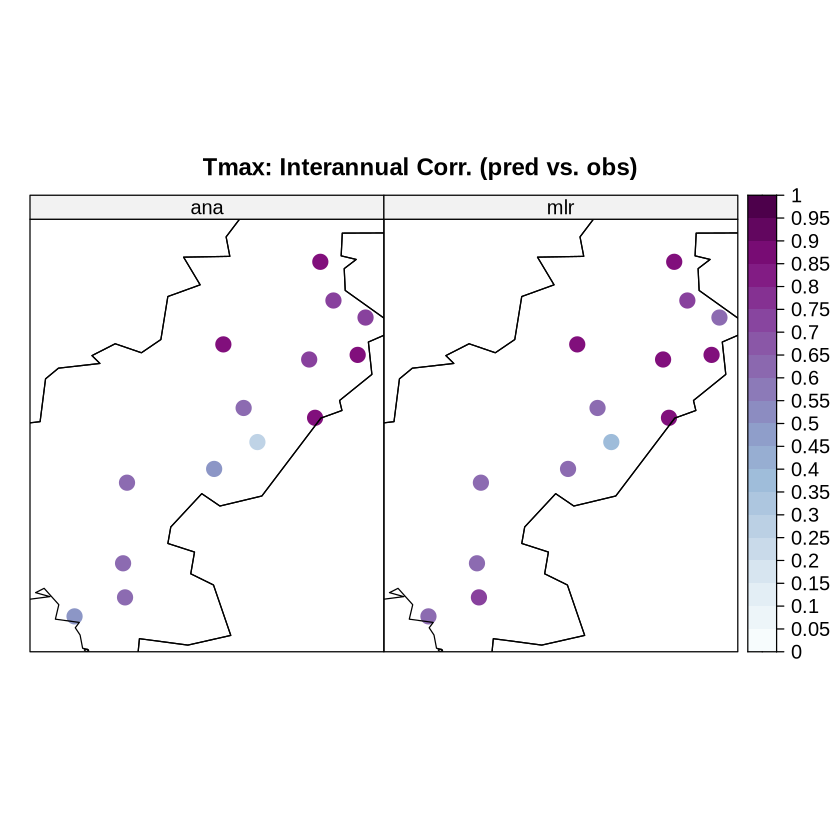

In [12]:
## interannual correlation ##
rho.y.ana = valueMeasure(y.obs, y.pred.ana, measure.code = "ts.rpY")
rho.y.mlr = valueMeasure(y.obs, y.pred.mlr, measure.code = "ts.rpY")
cols = brewer.pal(9, "BuPu")
cb.bins = seq(0, 1, 0.05)
spatialPlot(makeMultiGrid(rho.y.ana$Measure, rho.y.mlr$Measure), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Tmax: Interannual Corr. (pred vs. obs)",
            names.attr = c("ana", "mlr"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

## 6. Preparing the GCM Predictors for Statistical Downscaling 

Once the statistical downscaling methods have been evaluated using ERA5 reanalysis data as predictors (i.e. under the PP-SD approach), the next step is to prepare the Global Climate Model (GCM) predictors that will be used to generate climate projections. In this example, the CanESM2 model is selected. Both the historical and a future (e.g. RCP85) scenarios are needed to obtain the downscaled delta signals. Let's start with the historical scenario.

The large-scale atmospheric variables are first loaded individually and interpolated onto the same 2.5º x 2.5º regular grid used for ERA5 during the calibration phase. Maintaining a common spatial grid is essential because the statistical relationships learned by the downscaling models are defined in terms of these predictor fields. After interpolation, the different variables are combined into a single multi-variable object, and their climatological fields are displayed to provide an overview of the atmospheric conditions represented by the GCM.

In [13]:
####################################################
## preparing GCM predictors (historical scenario) ##
####################################################

## loading CMIP5 predictors ##
gcm = "CanESM2"

## historical scenario ##
x.cmip5.hist = lapply(x, function(ivar) {
  print(sprintf("... loading and interpolating %s for %s (historical) ...", ivar, gcm))
  
  ## loading predictor data ##
  data = loadGridData(sprintf("%s/%s_historical_%s.nc", dirdata.cmip5, gcm, ivar),
                     var = ivar, lonLim = lon, latLim = lat,
                     years = 1986:2005)
  
  ## interpolating to a common 2.5º regular grid ##
  return(interpGrid(data, new.coordinates = getGrid(x.era5)))
})
x.cmip5.hist = makeMultiGrid(x.cmip5.hist)
x.cmip5.hist = redim(x.cmip5.hist, drop = TRUE)
getShape(x.cmip5.hist)
getGrid(x.cmip5.hist)
range(x.cmip5.hist$Dates)  # 1941-2005
x.cmip5.hist$Variable = x.era5$Variable  # harmonizing predictors' names

[1] "... loading and interpolating z850 for CanESM2 (historical) ..."


[2026-07-17 18:52:51.897686] Opening dataset...

[2026-07-17 18:52:52.488014] The dataset was successfuly opened

[2026-07-17 18:52:52.494673] Defining geo-location parameters

[2026-07-17 18:52:52.531853] Defining time selection parameters

[2026-07-17 18:52:52.637978] Retrieving data subset ...

[2026-07-17 18:52:54.628703] Done

[2026-07-17 18:52:54.635483] Calculating nearest neighbors...

[2026-07-17 18:52:54.640054] Performing nearest interpolation... may take a while

[2026-07-17 18:52:54.65806] Done



[1] "... loading and interpolating t850 for CanESM2 (historical) ..."


[2026-07-17 18:52:54.879027] Opening dataset...

[2026-07-17 18:52:55.283885] The dataset was successfuly opened

[2026-07-17 18:52:55.28978] Defining geo-location parameters

[2026-07-17 18:52:55.344252] Defining time selection parameters

[2026-07-17 18:52:55.440435] Retrieving data subset ...

[2026-07-17 18:52:57.358578] Done

[2026-07-17 18:52:57.36402] Calculating nearest neighbors...

[2026-07-17 18:52:57.366208] Performing nearest interpolation... may take a while

[2026-07-17 18:52:57.373546] Done



var time  lat  lon 
   2 7300    5    5

$x
[1] 65 75

$y
[1] 24.5 34.5

attr(,"resX")
[1] 2.5
attr(,"resY")
[1] 2.5
attr(,"projection")
[1] "LatLonProjection"
attr(,"interpolation")
[1] "nearest"

[1] "1986-01-01 12:00:00 GMT" "2005-12-31 12:00:00 GMT"

[2026-07-17 18:52:57.514307] - Computing climatology...

[2026-07-17 18:52:57.519888] - Done.

[2026-07-17 18:52:57.54613] - Computing climatology...

[2026-07-17 18:52:57.551584] - Done.



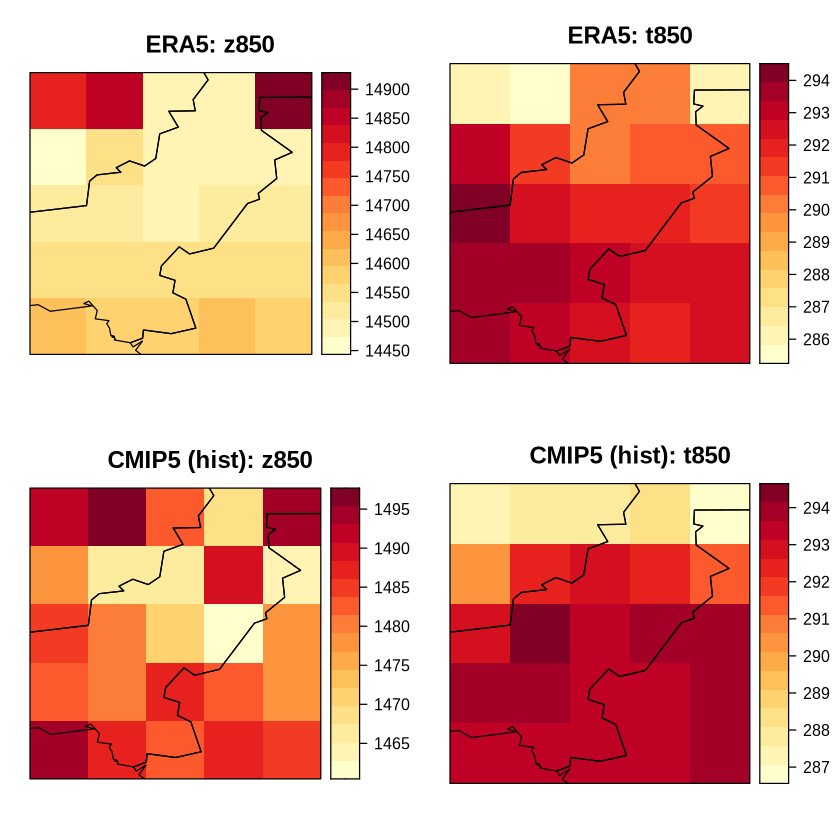

In [14]:
## plotting raw CMIP5 predictor's climatologies ##
clim.x.cmip5.hist = lapply(1:getShape(x.cmip5.hist)["var"], function(ivar) {
  x.cmip5.hist.var = subsetDimension(x.cmip5.hist, dimension = "var", indices = ivar)
  spatialPlot(climatology(x.cmip5.hist.var), backdrop.theme = "countries",
              color.theme = "YlOrRd",
              main = sprintf("CMIP5 (hist): %s", x[ivar]))
})
grid.arrange(grobs = c(clim.x.era5, clim.x.cmip5.hist),
             nrow = 2)

Although GCM and ERA5 datasets describe the same physical variables, systematic differences often exist due to model biases. If left untreated, these discrepancies may degrade the performance of the statistical downscaling model, since it was calibrated using ERA5 rather than GCM data.

To improve the consistency between both datasets, the GCM predictors are centred with respect to the ERA5 climatology using a monthly scaling procedure. This preprocessing step adjusts the mean state of each predictor while preserving its temporal variability, producing predictor fields that are statistically more compatible with those used during model calibration. The climatological maps shown before and after processing allow the effect of this adjustment to be visually assessed.

In [15]:
## harmonizing historical CMIP5 predictor data (to make it compatible with ERA5) ##
x.cmip5.hist.proc = scaleGrid(x.cmip5.hist, 
                         base = x.cmip5.hist, 
                         ref = x.era5, 
                         type = "center", 
                         spatial.frame = "gridbox", 
                         time.frame = "monthly")

[2026-07-17 18:53:06.453799] - Scaling by months ...

[2026-07-17 18:53:06.783738] - Done



[2026-07-17 18:53:06.800226] - Computing climatology...

[2026-07-17 18:53:06.803216] - Done.

[2026-07-17 18:53:06.828053] - Computing climatology...

[2026-07-17 18:53:06.831378] - Done.



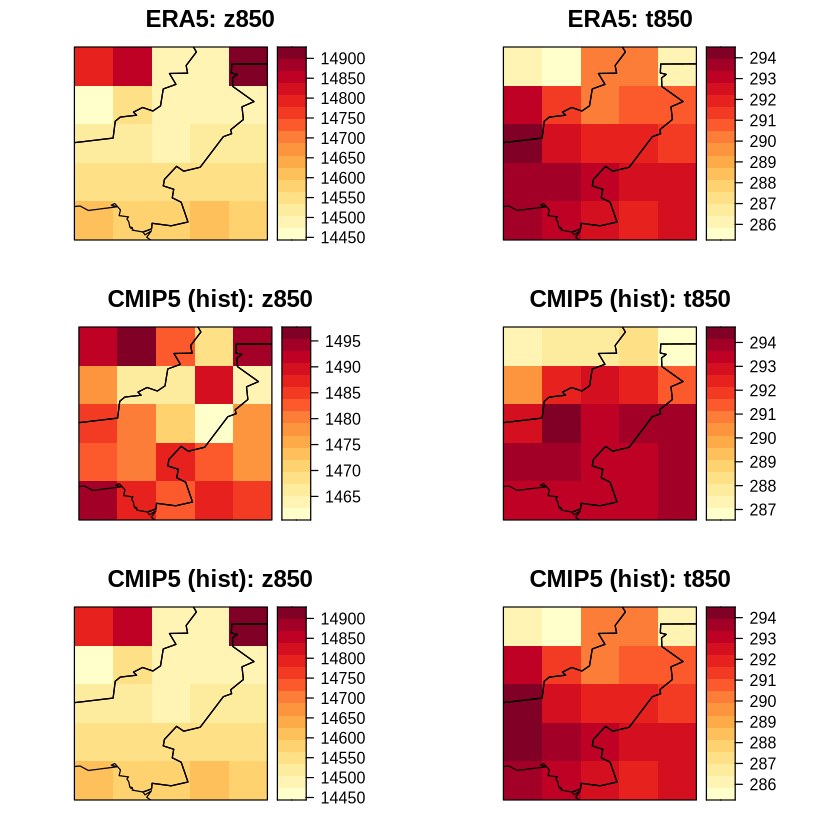

In [16]:
## plotting harmonized historical CMIP5 predictor's climatologies ##
clim.x.cmip5.hist.proc = lapply(1:getShape(x.cmip5.hist.proc)["var"], function(ivar) {
  clim.x.cmip5.hist.proc.var = subsetDimension(x.cmip5.hist.proc, dimension = "var", indices = ivar)
  spatialPlot(climatology(clim.x.cmip5.hist.proc.var), backdrop.theme = "countries",
              color.theme = "YlOrRd",
              main = sprintf("CMIP5 (hist): %s", x[ivar]))
})

grid.arrange(grobs = c(clim.x.era5, 
                       clim.x.cmip5.hist,
                       clim.x.cmip5.hist.proc),
             nrow = 3)

After processing the GCM predictors for the historical scenario, the same workflow is applied for the RCP8.5 scenario. First, the large-scale atmospheric predictors are loaded, interpolated onto the common 2.5º x 2.5º grid, and combined into a multi-variable dataset with the same structure and variable names used during the calibration of the statistical downscaling models.

As for the historical simulation, the future predictor fields must be made statistically compatible with the ERA5 reanalysis before they can be used for downscaling. However, this adjustment requires particular care. The objective is to remove the systematic differences between the GCM and the reanalysis while preserving the climate change signal simulated by the GCM.

To achieve this, the future (i.e. RCP8.5) predictors are centred using the historical GCM simulation as the baseline and the ERA5 reanalysis as the reference. This approach corrects the mean-state differences between the GCM and ERA5 without artificially removing the projected changes contained in the future GCM simulation. The processed climatological fields are then visualised and compared with the ERA5 and processed historical climatologies to verify that the predictor fields have become statistically consistent while retaining their projected future evolution.

In [17]:
########################################
## preparing GCM predictors (RCP 8.5) ##
########################################

## RCP8.5 ##
x.cmip5.rcp85 = lapply(x, function(ivar) {
  print(sprintf("... loading and interpolating %s for %s (rcp85) ...", ivar, gcm))
  
  ## loading predictor data ##
  data = loadGridData(sprintf("%s/%s_rcp85_%s.nc", dirdata.cmip5, gcm, ivar),
                     var = ivar, lonLim = lon, latLim = lat,
                     years = 2061:2099)

  ## interpolating to a common 2.5º regular grid ##
  return(interpGrid(data, new.coordinates = getGrid(x.era5)))
    
})
x.cmip5.rcp85 = makeMultiGrid(x.cmip5.rcp85)
x.cmip5.rcp85 = redim(x.cmip5.rcp85, drop = TRUE)
getShape(x.cmip5.rcp85)
getGrid(x.cmip5.rcp85)
range(x.cmip5.rcp85$Dates)
x.cmip5.rcp85$Variable = x.era5$Variable  # harmonizing predictors' names

[1] "... loading and interpolating z850 for CanESM2 (rcp85) ..."


[2026-07-17 18:53:19.446877] Opening dataset...

[2026-07-17 18:53:20.136549] The dataset was successfuly opened

[2026-07-17 18:53:20.145301] Defining geo-location parameters

[2026-07-17 18:53:20.183607] Defining time selection parameters

[2026-07-17 18:53:20.337311] Retrieving data subset ...

[2026-07-17 18:53:24.885942] Done

[2026-07-17 18:53:24.910289] Calculating nearest neighbors...

[2026-07-17 18:53:24.915043] Performing nearest interpolation... may take a while

[2026-07-17 18:53:24.958735] Done



[1] "... loading and interpolating t850 for CanESM2 (rcp85) ..."


[2026-07-17 18:53:25.16528] Opening dataset...

[2026-07-17 18:53:25.699349] The dataset was successfuly opened

[2026-07-17 18:53:25.704598] Defining geo-location parameters

[2026-07-17 18:53:25.757371] Defining time selection parameters

[2026-07-17 18:53:25.928808] Retrieving data subset ...

[2026-07-17 18:53:30.413505] Done

[2026-07-17 18:53:30.420622] Calculating nearest neighbors...

[2026-07-17 18:53:30.422275] Performing nearest interpolation... may take a while

[2026-07-17 18:53:30.431834] Done



var  time   lat   lon 
    2 14235     5     5

$x
[1] 65 75

$y
[1] 24.5 34.5

attr(,"resX")
[1] 2.5
attr(,"resY")
[1] 2.5
attr(,"projection")
[1] "LatLonProjection"
attr(,"interpolation")
[1] "nearest"

[1] "2061-01-01 12:00:00 GMT" "2099-12-31 12:00:00 GMT"

In [18]:
## harmonizing future CMIP5 predictor data (to make it compatible with ERA5 whilst retaining the GCM's climate change signal) ##
x.cmip5.rcp85.proc = scaleGrid(x.cmip5.rcp85, 
                              base = x.cmip5.hist, 
                              ref = x.era5, 
                              type = "center", 
                              spatial.frame = "gridbox", 
                              time.frame = "monthly")

[2026-07-17 18:53:30.720311] - Scaling by months ...

[2026-07-17 18:53:31.25256] - Done



[2026-07-17 18:53:31.267851] - Computing climatology...

[2026-07-17 18:53:31.272232] - Done.

[2026-07-17 18:53:31.298811] - Computing climatology...

[2026-07-17 18:53:31.304188] - Done.



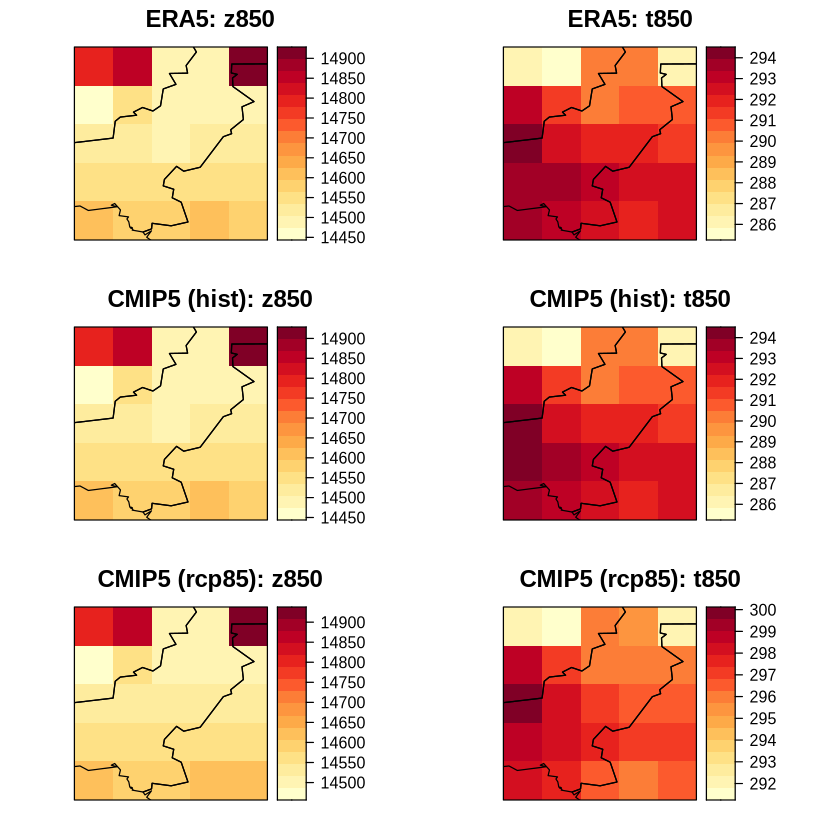

In [19]:
## plotting harmonized future CMIP5 predictor's climatologies ##
clim.x.cmip5.rcp85.proc = lapply(1:getShape(x.cmip5.rcp85.proc)["var"], function(ivar) {
  clim.x.cmip5.rcp85.proc.var = subsetDimension(x.cmip5.rcp85.proc, dimension = "var", indices = ivar)
  spatialPlot(climatology(clim.x.cmip5.rcp85.proc.var), backdrop.theme = "countries",
              color.theme = "YlOrRd",
              main = sprintf("CMIP5 (rcp85): %s", x[ivar]))
})

grid.arrange(grobs = c(clim.x.era5, 
                       #clim.x.cmip5.hist,
                       clim.x.cmip5.hist.proc,
                       clim.x.cmip5.rcp85.proc),
             nrow = 3)

## 7. Generating Local Downscaled Climate Projections
Having calibrated and evaluated the statistical downscaling methods, the final step is to apply them to the Global Climate Model (GCM) simulations. The processed GCM predictors prepared in the previous sections are now used as input to generate local-scale projections of maximum temperature for both the historical and future (RCP8.5) scenarios. These downscaled datasets constitute the final product of the statistical downscaling workflow and will be analysed in the following sections.

As we did for the cross-validation experiment, two different statistical methods are considered at this point: Analogs and Multiple Linear Regression (MLR). In both cases, the predictor space is first reduced using the leading 15 principal components, providing a compact representation of the large-scale atmospheric circulation (approximately the 80% of variance) while reducing redundancy among the predictor variables.

In [20]:
## mlr ##
y.hist.mlr <- downscale(y = y.obs, 
                        x = x.era5, 
                        newdata = x.cmip5.hist.proc, 
                        method = "lm", 
                        n.pcs = 15) 

[2026-07-17 18:53:44.683666] - Scaling ...

[2026-07-17 18:53:44.976891] - Done

[2026-07-17 18:53:44.978693] - Scaling ...

[2026-07-17 18:53:45.287276] - Done



In [21]:
## mlr ##
y.rcp85.mlr <- downscale(y = y.obs, 
                         x = x.era5, 
                         newdata = x.cmip5.rcp85.proc, 
                         method = "lm", 
                         n.pcs = 10) 

[2026-07-17 18:53:46.86441] - Scaling ...

[2026-07-17 18:53:47.552698] - Done

[2026-07-17 18:53:47.553909] - Scaling ...

[2026-07-17 18:53:48.259057] - Done



The downscaled values are now used to examine how maximum temperature is projected to evolve throughout the twenty-first century. For both the Analogs and Multiple Linear Regression (MLR) methods, climatologies are computed for the historical reference period (1986-2005) and for two future time slices under the RCP8.5 scenario: the mid-century period (2061-2080) and the late-century period (2081–2099).

Displaying these climatologies side by side provides a straightforward way to visualise the progressive warming projected by the GCM after statistical downscaling. Because the results are presented at the meteorological stations, the maps illustrate how projected temperature changes vary across the region of study at the local scale, highlighting both regional differences and the temporal evolution of the warming signal.

These maps provide the basis for the subsequent analysis of climate change signals, in which historical and future climatologies are directly compared to quantify the magnitude and spatial distribution of projected warming.

[2026-07-17 18:53:48.993585] - Computing climatology...

[2026-07-17 18:53:49.016534] - Done.

[2026-07-17 18:53:49.035932] - Computing climatology...

[2026-07-17 18:53:49.040802] - Done.

[2026-07-17 18:53:49.060041] - Computing climatology...

[2026-07-17 18:53:49.06308] - Done.



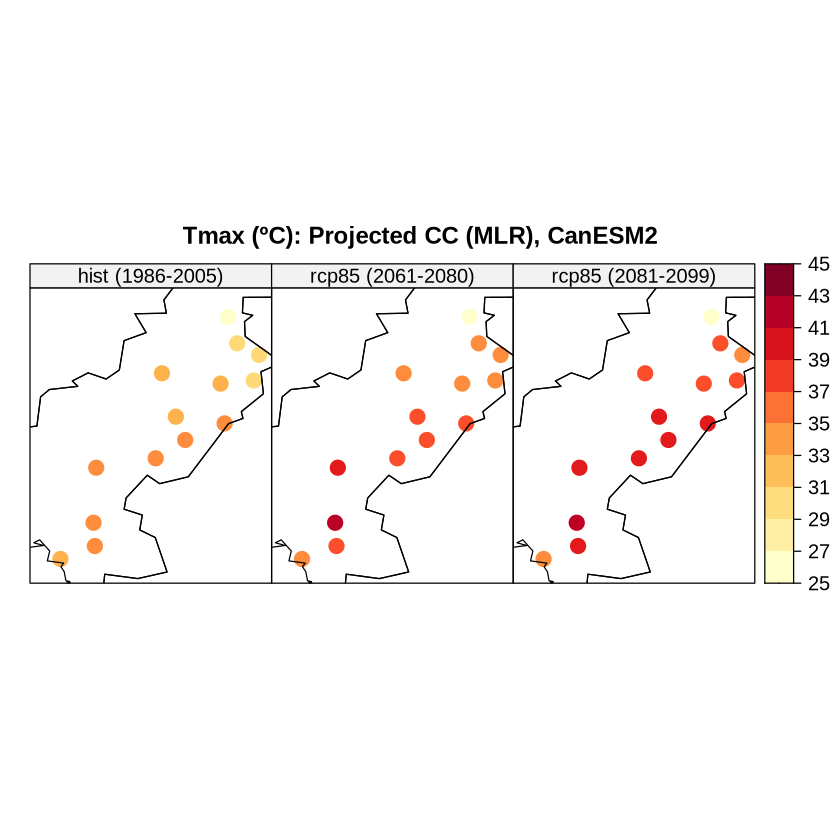

In [22]:
## projections: mlr ##
clim.hist.mlr = climatology(subsetGrid(y.hist.mlr, years = 1986:2005))
clim.rcp85.mid.mlr = climatology(subsetGrid(y.rcp85.mlr, years = 2061:2080))
clim.rcp85.far.mlr = climatology(subsetGrid(y.rcp85.mlr, years = 2081:2099))

cols = brewer.pal(9, "YlOrRd")
cb.bins = seq(25, 45, 2)
spatialPlot(makeMultiGrid(clim.hist.mlr, 
                          clim.rcp85.mid.mlr,
                          clim.rcp85.far.mlr,
                          skip.temporal.check = TRUE), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Tmax (ºC): Projected CC (MLR), CanESM2",
            names.attr = c("hist (1986-2005)", "rcp85 (2061-2080)", "rcp85 (2081-2099)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

To quantify the projected warming, climate change signals (deltas) are computed by subtracting the downscaled historical climatology (1986-2005) from the downscaled future climatologies corresponding to the mid-century (2061-2080) and late-century (2081-2099) periods. The resulting maps represent the projected increase in mean daily maximum temperature at each meteorological station relative to the historical baseline.

The climate change signals are calculated independently for the Analogs and Multiple Linear Regression (MLR) downscaling methods, allowing their projections to be directly compared. Presenting the four maps together facilitates the assessment of both the temporal evolution of warming and the consistency between the two statistical approaches.

Unlike the previous figures, which displayed absolute climatological temperatures, these delta maps isolate the projected climate change signal, making it easier to identify regional differences in the magnitude of future warming. Areas exhibiting larger positive deltas are expected to experience stronger increases in maximum temperature.

These downscaled climate change signals constitute the final output of the statistical downscaling workflow and represent the information typically required for climate change impact assessments at the local scale.

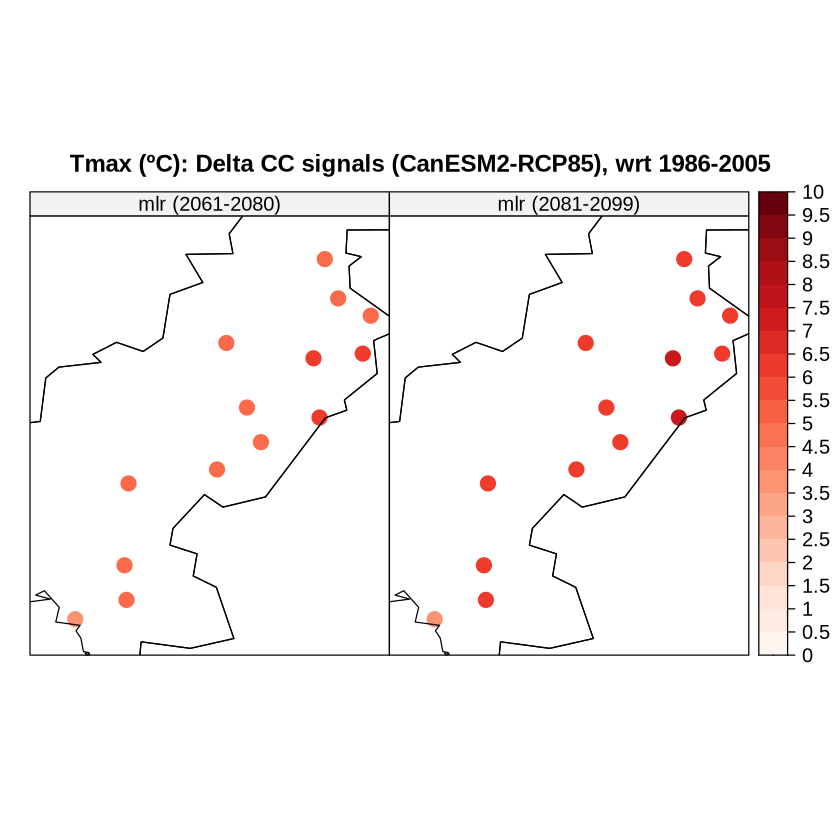

In [23]:
## deltas for mlr ##
delta.rcp85.mid.mlr = gridArithmetics(clim.rcp85.mid.mlr,
                                      clim.hist.mlr, 
                                      operator = "-")
delta.rcp85.far.mlr = gridArithmetics(clim.rcp85.far.mlr,
                                      clim.hist.mlr, 
                                      operator = "-")

cols = brewer.pal(9, "Reds")
cb.bins = seq(0, 10, 0.5)
spatialPlot(makeMultiGrid(delta.rcp85.mid.mlr,
                          delta.rcp85.far.mlr,
                          skip.temporal.check = TRUE), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Tmax (ºC): Delta CC signals (CanESM2-RCP85), wrt 1986-2005",
            names.attr = c("mlr (2061-2080)",
                           "mlr (2081-2099)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

## 8. Assessing Local Future Projections: Karachi Airport

While the previous sections examined the spatial distribution of projected climate change across Pakistan, it is often useful to analyse the projected evolution at individual locations. Now, the downscaled projections are extracted for the Karachi airport meteorological station, providing an example of how statistical downscaling can be used to investigate local climate change.

Daily data are first yearly aggregated, allowing the long-term evolution of the climate to be more easily visualised by filtering out day-to-day variability. Annual time series are then extracted for the observed records, the downscaled historical simulation and the downscaled future RCP8.5 projection, using both the Analogs and Multiple Linear Regression (MLR) methods.

Displaying these series together makes it possible to evaluate the continuity between the historical and future simulations and to compare the behaviour of the two downscaling techniques. The historical simulations can be contrasted with the observations to assess how well each method reproduces the recent climate, while the future projections illustrate the expected evolution of annual maximum temperatures throughout the twenty-first century under a high-emission scenario.

This station-based analysis complements the spatial maps presented earlier by providing a clearer picture of the temporal evolution of climate change at a specific location, illustrating one of the main advantages of statistical downscaling: the generation of local climate projections directly at observation sites.

[2026-07-17 18:53:58.013567] Performing annual aggregation...

[2026-07-17 18:53:58.020955] Done.

[2026-07-17 18:53:58.031353] Performing annual aggregation...

[2026-07-17 18:53:58.035495] Done.

[2026-07-17 18:53:58.049866] Performing annual aggregation...

[2026-07-17 18:53:58.056294] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



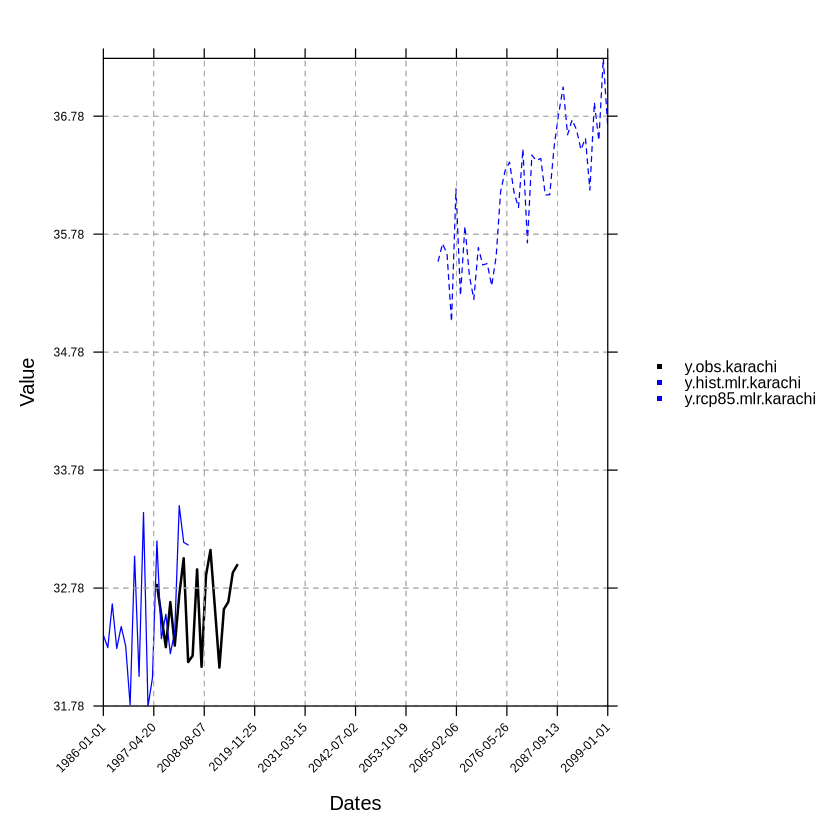

In [24]:
#################################################################
## local downscaled projections (time-series): Karachi airport ##
#################################################################

## karachi (airport) ##
lon.karachi = 67.133 
lat.karachi = 24.9

## yearly time series ##
y.obs.karachi = subsetGrid(aggregateGrid(y.obs, aggr.y = list(FUN = "mean")), 
                                lonLim = lon.karachi, latLim = lat.karachi)

y.hist.mlr.karachi = subsetGrid(aggregateGrid(y.hist.mlr, aggr.y = list(FUN = "mean")), 
                                lonLim = lon.karachi, latLim = lat.karachi)
y.rcp85.mlr.karachi = subsetGrid(aggregateGrid(y.rcp85.mlr, aggr.y = list(FUN = "mean")), 
                                 lonLim = lon.karachi, latLim = lat.karachi)

## plotting ##
temporalPlot(y.obs.karachi,
             y.hist.mlr.karachi, y.rcp85.mlr.karachi,
             cols = c("black", "blue", "blue"),
             lty = c(1, 1, 2),
             lwd = c(2, 1, 1))

## 9. Applying the Workflow to Obtain Statistical Downscaling of Daily Precipitation

Following the same general workflow developed for maximum temperature, the rest of the notebook is dedicated to obtain local downscaled climate change projections of daily precipitation at the station level por Pakistan. However, precipitation presents additional challenges because it is an intermittent variable, characterised by a large number of dry days and a highly skewed distribution of rainfall amounts. As a result, precipitation typically requires different statistical models from those used for temperatures.

The observed daily precipitation records (i.e. the predictand hereafter) are first loaded and temporally aligned with the ERA5 predictor dataset. Two statistical downscaling approaches are then evaluated using a two-fold chronological cross-validation. The first is the Analogs method. The second is a Generalized Linear Model (GLM) specifically designed for precipitation. This GLM adopts a two-step modelling strategy: a logistic regression is first used to predict the occurrence of wet days, followed by a Gamma regression to estimate rainfall amounts on days classified as wet. The final precipitation series is obtained by combining the outputs of these two components.

The performance of both downscaling methods is evaluated using the same validation framework employed for temperature. Spatial maps of the predicted climatologies are first compared with the observations, followed by three complementary validation metrics: mean bias, daily correlation, and interannual correlation. Together, these diagnostics assess the ability of each method to reproduce the observed mean precipitation, day-to-day variability and year-to-year fluctuations.

After validation, the calibrated statistical models are applied to the processed CanESM2 predictor fields for both the historical and RCP8.5 simulations. This produces downscaled precipitation series at every meteorological station, from which climatological maps are computed for the historical reference period (1986-2005) and two future periods (2061-2080 and 2081-2099). Climate change signals are subsequently calculated by comparing the future and historical climatologies, allowing the projected changes in mean precipitation to be analysed and compared between the Analogs and GLM approaches.

Finally, the notebook illustrates the local evolution of precipitation by extracting annual precipitation totals for two contrasting meteorological stations: Karachi airport, located in the arid coastal region of southern Pakistan, and Murree, situated in the wetter mountainous north. Examining these station-based time series complements the spatial analyses by showing how projected precipitation evolves through time at individual locations and highlighting regional differences in the climate change response.

In [25]:
###################
## precipitation ##
###################

## loading observed predictand ## 
y = "pr"
load(sprintf("%s/%s.rda", dirdata.obs, y)) 
y.obs = data; rm(data)
getShape(y.obs)
range(y.obs$Dates$start)
y.obs$Dates$start = x.era5$Dates[[1]]$start  # harmonizing predictors and predictand dates
y.obs$Dates$end = x.era5$Dates[[1]]$end

time  loc 
7295   14

[1] "1997-01-01 00:00:00" "2016-12-31 00:00:00"

In [26]:
############################
## downscaling in CV mode ##
############################

## analogs ##
y.pred.ana = downscaleCV(x.era5, y.obs, 
                         method = "analogs", 
                         folds = 2, 
                         sampling.strategy = "kfold.chronological",
                         scaleGrid.args = list(type = "standardize"),
                         prepareData.args = list("spatial.predictors" = list(which.combine = getVarNames(x.era5), v.exp = 0.8)))
getShape(y.pred.ana)

fold: 1 --> calculating...

[2026-07-17 18:53:58.408441] - Scaling ...

[2026-07-17 18:53:58.50699] - Done

[2026-07-17 18:53:58.508165] - Scaling ...

[2026-07-17 18:53:58.629921] - Done

[2026-07-17 18:53:58.688763] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:53:58.74356] Done.

fold: 2 --> calculating...

[2026-07-17 18:54:04.403995] - Scaling ...

[2026-07-17 18:54:04.508991] - Done

[2026-07-17 18:54:04.510445] - Scaling ...

[2026-07-17 18:54:04.62794] - Done

[2026-07-17 18:54:04.684941] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:54:04.706919] Done.



time  loc 
7295   14

In [27]:
############################
## downscaling in CV mode ##
############################

## glm ##

## occurrence glm (logistic regression) ##
y.obs.occ = binaryGrid(y.obs, condition = "GE", threshold = 1)
y.pred.glm.occ = downscaleCV(x.era5, y.obs.occ,  
                         method = "GLM", family = binomial(link = "logit"),
                         folds = 2,
                         sampling.strategy = "kfold.chronological",
                         scaleGrid.args = list(type = "standardize"),
                         prepareData.args = list("spatial.predictors" = list(which.combine = getVarNames(x.era5), v.exp = 0.8)))
y.pred.glm.occ = subsetGrid(y.pred.glm.occ, var = "bin")

fold: 1 --> calculating...

[2026-07-17 18:54:09.774597] - Scaling ...

[2026-07-17 18:54:09.906289] - Done

[2026-07-17 18:54:09.908044] - Scaling ...

[2026-07-17 18:54:10.018303] - Done

[2026-07-17 18:54:10.080005] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:54:10.130714] Done.

fold: 2 --> calculating...

[2026-07-17 18:54:10.311566] - Scaling ...

[2026-07-17 18:54:10.439354] - Done

[2026-07-17 18:54:10.441188] - Scaling ...

[2026-07-17 18:54:10.549883] - Done

[2026-07-17 18:54:10.615827] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:54:10.639269] Done.



In [28]:
## amount glm ##
y.pred.glm.amo = downscaleCV(x.era5, y.obs,  
                             method = "GLM", family = Gamma(link = "log"),
                             condition = "GE", threshold = 1,
                             folds = 2,
                             sampling.strategy = "kfold.chronological",
                             scaleGrid.args = list(type = "standardize"),
                             prepareData.args = list("spatial.predictors" = list(which.combine = getVarNames(x.era5), v.exp = 0.8)))

fold: 1 --> calculating...

[2026-07-17 18:54:10.949476] - Scaling ...

[2026-07-17 18:54:11.103207] - Done

[2026-07-17 18:54:11.106577] - Scaling ...

[2026-07-17 18:54:11.2276] - Done

[2026-07-17 18:54:11.287134] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:54:11.322736] Done.

fold: 2 --> calculating...

[2026-07-17 18:54:11.385439] - Scaling ...

[2026-07-17 18:54:11.493693] - Done

[2026-07-17 18:54:11.495191] - Scaling ...

[2026-07-17 18:54:11.62092] - Done

[2026-07-17 18:54:11.677585] Performing PC analysis on 2 variables plus a combination ...

[2026-07-17 18:54:11.729588] Done.



In [29]:
## complete precipitation series ##
y.pred.glm = gridArithmetics(y.pred.glm.occ, y.pred.glm.amo, operator = "*")
getShape(y.pred.glm)

time  loc 
7295   14

[2026-07-17 18:54:11.848768] - Computing climatology...

[2026-07-17 18:54:11.85062] - Done.

[2026-07-17 18:54:11.854266] - Computing climatology...

[2026-07-17 18:54:11.856007] - Done.

[2026-07-17 18:54:11.859108] - Computing climatology...

[2026-07-17 18:54:11.861157] - Done.



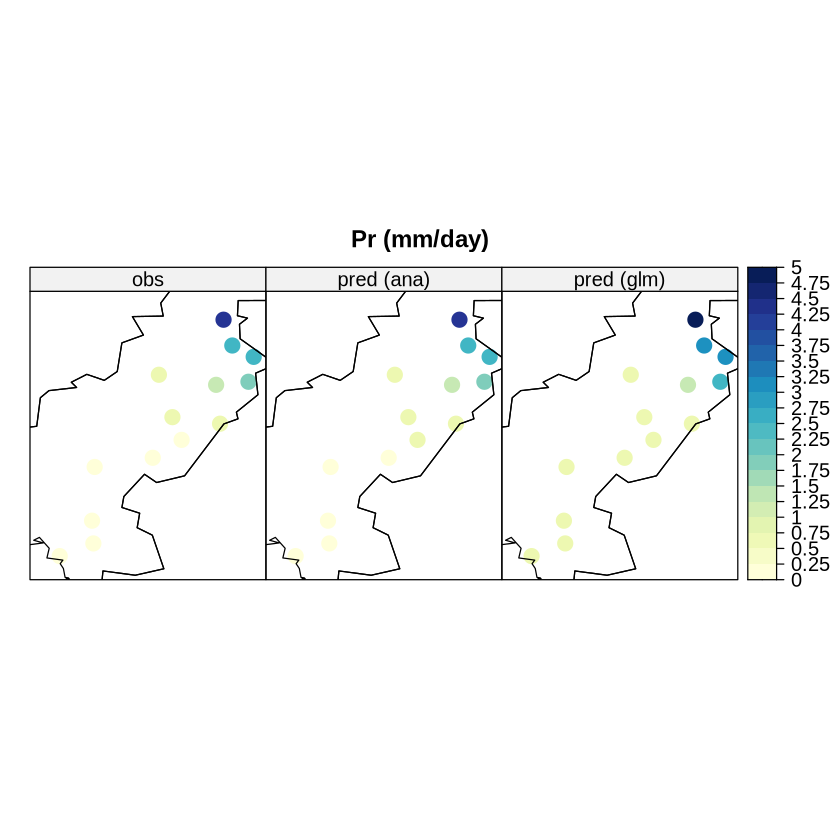

In [30]:
## plotting the predictions ##
cols = brewer.pal(9, "YlGnBu")
cb.bins = seq(0, 5, 0.25)
spatialPlot(makeMultiGrid(climatology(y.obs), 
                          climatology(y.pred.ana),
                          climatology(y.pred.glm)), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Pr (mm/day)",
            names.attr = c("obs", "pred (ana)", "pred (glm)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1, 
                                                                              labels = cb.bins))))))

[2026-07-17 18:54:16.745445] - Computing climatology...

[2026-07-17 18:54:16.748076] - Done.

[2026-07-17 18:54:16.752164] - Computing climatology...

[2026-07-17 18:54:16.754227] - Done.

[2026-07-17 18:54:16.759323] - Computing climatology...

[2026-07-17 18:54:16.761214] - Done.

[2026-07-17 18:54:16.764627] - Computing climatology...

[2026-07-17 18:54:16.766356] - Done.



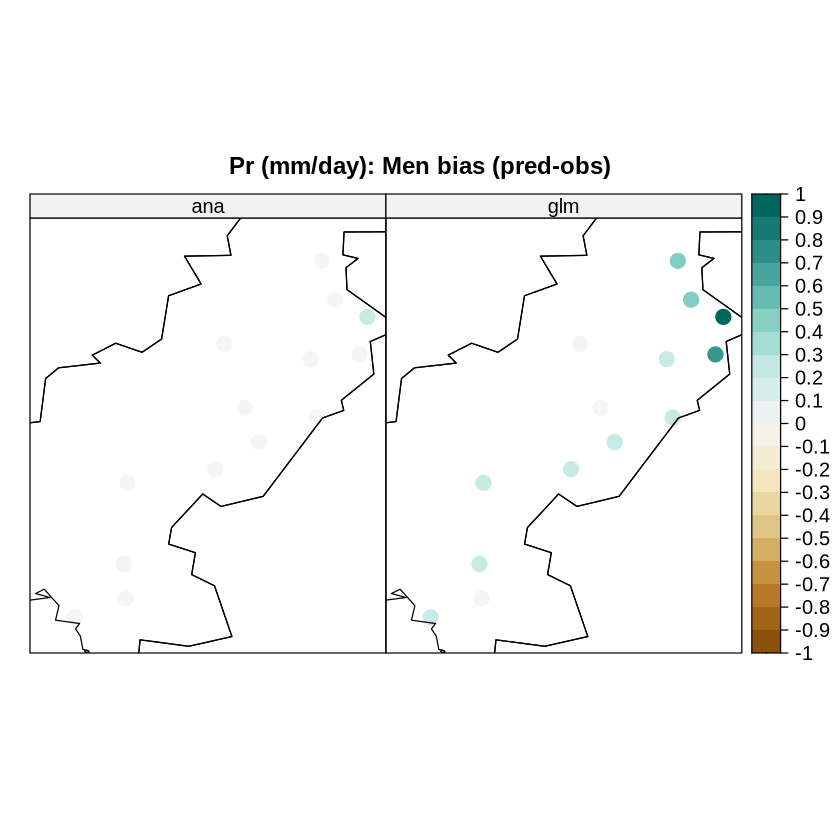

In [31]:
################################
## validating the predictions ##
################################

## mean bias ##
bias.ana = gridArithmetics(climatology(y.pred.ana), 
                           climatology(y.obs), operator = "-")
bias.glm = gridArithmetics(climatology(y.pred.glm), 
                           climatology(y.obs), operator = "-")
cols = brewer.pal(9, "BrBG")
cb.bins = seq(-1, 1, 0.1)
spatialPlot(makeMultiGrid(bias.ana, bias.glm), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Pr (mm/day): Men bias (pred-obs)",
            names.attr = c("ana", "glm"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

[2026-07-17 18:54:20.233205] Computing member 1 out of 1

[2026-07-17 18:54:20.254609] Done.

[2026-07-17 18:54:20.262401] Computing member 1 out of 1

[2026-07-17 18:54:20.285289] Done.



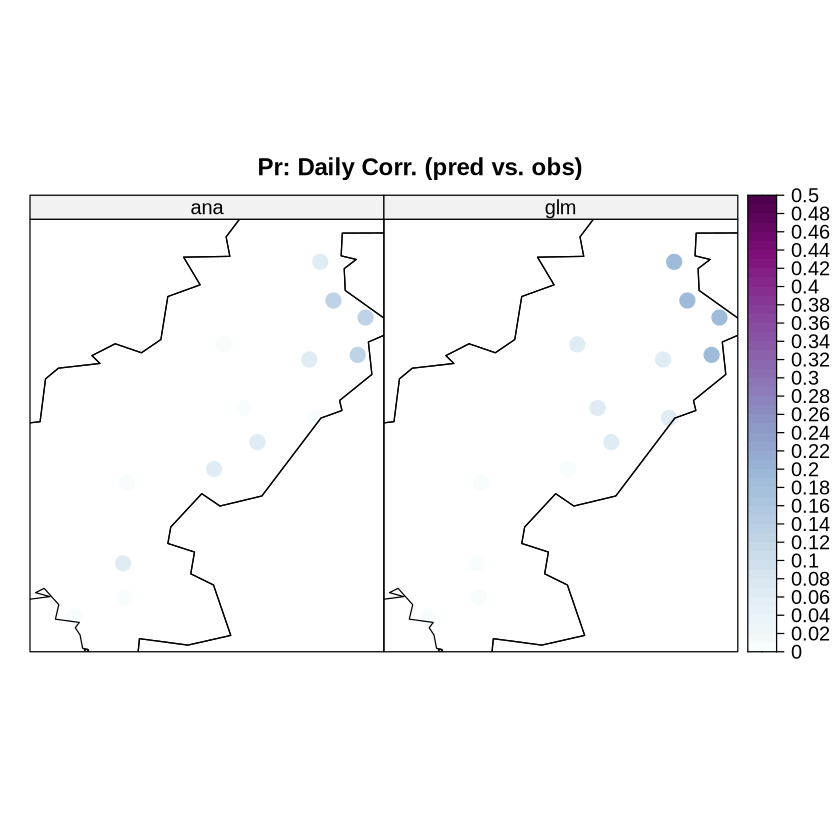

In [32]:
## daily correlation ##
rho.ana = valueMeasure(y.obs, y.pred.ana, measure.code = "ts.rp")
rho.glm = valueMeasure(y.obs, y.pred.glm, measure.code = "ts.rp")
cols = brewer.pal(9, "BuPu")
cb.bins = seq(0, 0.5, 0.01)
spatialPlot(makeMultiGrid(rho.ana$Measure, rho.glm$Measure),
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Pr: Daily Corr. (pred vs. obs)",
            names.attr = c("ana", "glm"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins[seq(1, length(cb.bins), 2)],
                                                                              cex = 1,
                                                                              labels = cb.bins[seq(1, length(cb.bins), 2)]))))))

[2026-07-17 18:54:23.822639] Computing member 1 out of 1

[2026-07-17 18:54:23.857425] Done.

[2026-07-17 18:54:23.865315] Computing member 1 out of 1

[2026-07-17 18:54:23.90046] Done.



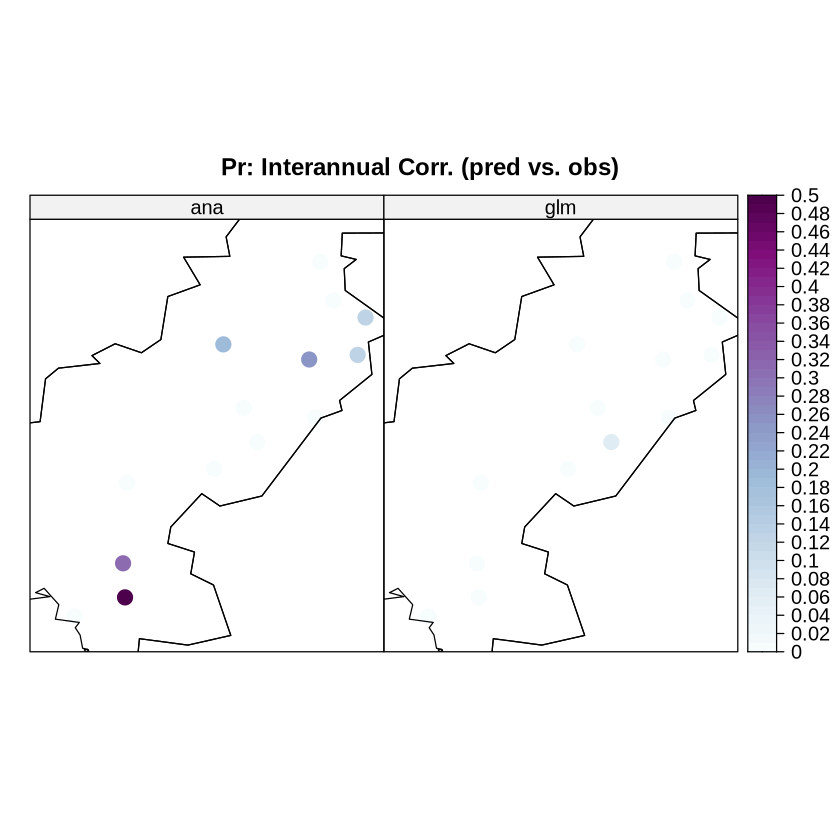

In [33]:
## interannual correlation ##
rho.y.ana = valueMeasure(y.obs, y.pred.ana, measure.code = "ts.rpY")
rho.y.glm = valueMeasure(y.obs, y.pred.glm, measure.code = "ts.rpY")
cols = brewer.pal(9, "BuPu")
cb.bins = seq(0, 0.5, 0.01)
spatialPlot(makeMultiGrid(rho.y.ana$Measure, rho.y.glm$Measure), 
            xlim = lon, ylim = lat,            
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Pr: Interannual Corr. (pred vs. obs)",
            names.attr = c("ana", "glm"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins[seq(1, length(cb.bins), 2)],
                                                                              cex = 1,
                                                                              labels = cb.bins[seq(1, length(cb.bins), 2)]))))))

In [34]:
## glm ##
y.hist.glm <- downscale(y = y.obs, 
                        x = x.era5, 
                        newdata = x.cmip5.hist.proc, 
                        method = "glm", 
                        wet.threshold = 1,
                        n.pcs = 15) 

y.hist.glm$Data[y.hist.glm$Data > 300] = NA  # manually fixing some issues with the glm method
y.hist.glm$Dates$start = x.cmip5.hist.proc$Dates[[1]]$start
y.hist.glm$Dates$end = x.cmip5.hist.proc$Dates[[1]]$end

[2026-07-17 18:54:28.577643] - Scaling ...

[2026-07-17 18:54:28.91211] - Done

[2026-07-17 18:54:28.914014] - Scaling ...

[2026-07-17 18:54:29.288795] - Done

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“step size truncated due to divergence”
Warning message in value[[3L]](cond):
“... couldn't create model for point 9 out of 14 ...”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


In [35]:
## glm ##
y.rcp85.glm <- downscale(y = y.obs, 
                         x = x.era5, 
                         newdata = x.cmip5.rcp85.proc, 
                         method = "glm",
                         wet.threshold = 1,
                         n.pcs = 35) 
y.rcp85.glm$Data[y.rcp85.glm$Data > 300] = NA  # manually fixing some issues with the glm method
y.rcp85.glm$Dates$start = x.cmip5.rcp85.proc$Dates[[1]]$start
y.rcp85.glm$Dates$end = x.cmip5.rcp85.proc$Dates[[1]]$end

[2026-07-17 18:54:32.197584] - Scaling ...

[2026-07-17 18:54:32.895642] - Done

[2026-07-17 18:54:32.896897] - Scaling ...

[2026-07-17 18:54:33.183345] - Done

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“step size truncated due to divergence”
Warning message in value[[3L]](cond):
“... couldn't create model for point 9 out of 14 ...”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


[2026-07-17 18:54:35.312114] - Computing climatology...

[2026-07-17 18:54:35.31629] - Done.

[2026-07-17 18:54:35.329912] - Computing climatology...

[2026-07-17 18:54:35.332837] - Done.

[2026-07-17 18:54:35.344753] - Computing climatology...

[2026-07-17 18:54:35.347582] - Done.



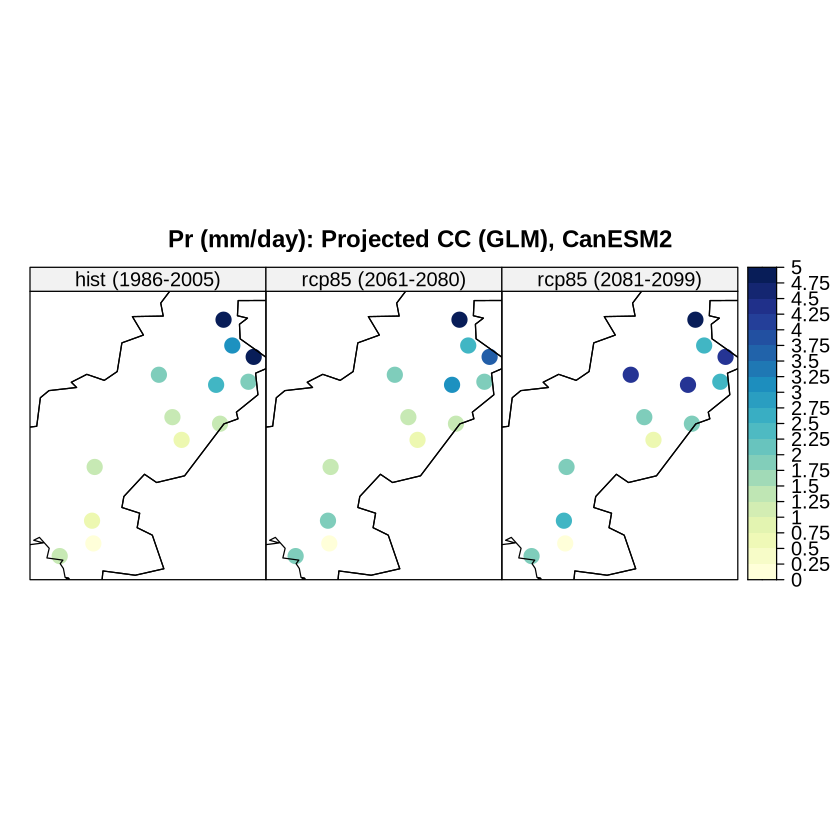

In [36]:
## projections: glm ##
clim.hist.glm = climatology(subsetGrid(y.hist.glm, years = 1986:2005))
clim.rcp85.mid.glm = climatology(subsetGrid(y.rcp85.glm, years = 2061:2080))
clim.rcp85.far.glm = climatology(subsetGrid(y.rcp85.glm, years = 2081:2099))

cols = brewer.pal(9, "YlGnBu")
cb.bins = seq(0, 5, 0.25)
spatialPlot(makeMultiGrid(clim.hist.glm, 
                          clim.rcp85.mid.glm,
                          clim.rcp85.far.glm,
                          skip.temporal.check = TRUE), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Pr (mm/day): Projected CC (GLM), CanESM2",
            names.attr = c("hist (1986-2005)", "rcp85 (2061-2080)", "rcp85 (2081-2099)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

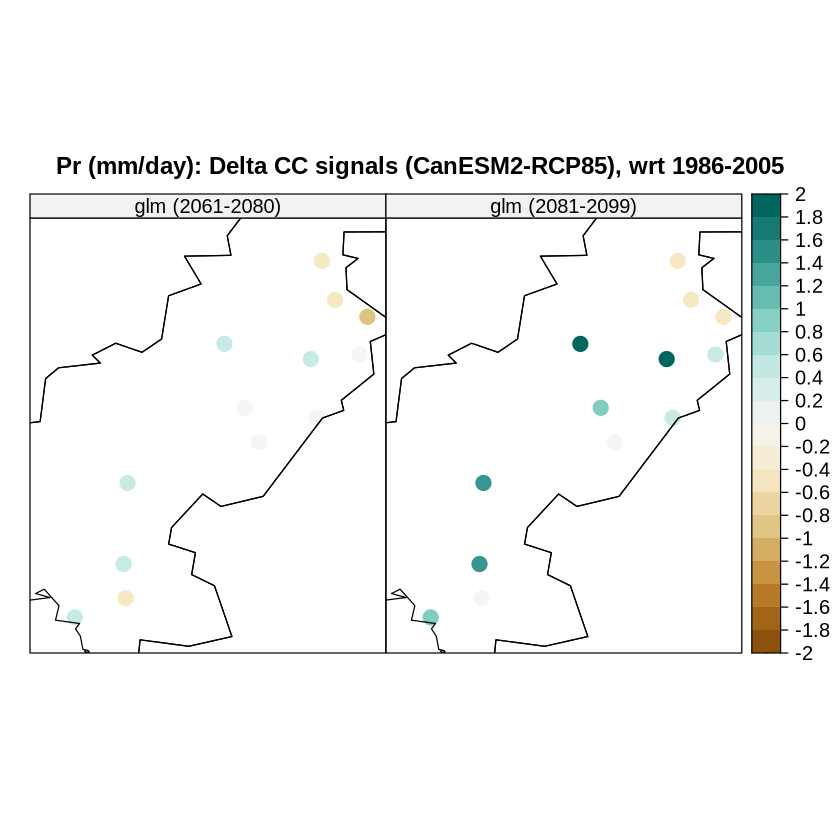

In [37]:
## deltas for glm ##
delta.rcp85.mid.glm = gridArithmetics(clim.rcp85.mid.glm,
                                      clim.hist.glm, 
                                      operator = "-")
delta.rcp85.far.glm = gridArithmetics(clim.rcp85.far.glm,
                                      clim.hist.glm, 
                                      operator = "-")

## plotting ##
cols = brewer.pal(9, "BrBG")
cb.bins = seq(-2, 2, 0.2)
spatialPlot(makeMultiGrid(delta.rcp85.mid.glm,
                          delta.rcp85.far.glm,
                          skip.temporal.check = TRUE), 
            xlim = lon, ylim = lat,
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Pr (mm/day): Delta CC signals (CanESM2-RCP85), wrt 1986-2005",
            names.attr = c("glm (2061-2080)",
                           "glm (2081-2099)"),
            pch = 19, cex = 1.5,
            col.regions = cols,
            set.min = min(cb.bins), set.max = max(cb.bins),
            cuts = cb.bins,
            colorkey = list(right = list(fun = draw.colorkey, 
                                         args = list(key = list(at = cb.bins, 
                                                                col = colorRampPalette(cols), 
                                                                labels = list(at = cb.bins,
                                                                              cex = 1,
                                                                              labels = cb.bins))))))

[2026-07-17 18:54:43.06231] Performing annual aggregation...

[2026-07-17 18:54:43.066567] Done.

[2026-07-17 18:54:43.076774] Performing annual aggregation...

[2026-07-17 18:54:43.080702] Done.

[2026-07-17 18:54:43.095773] Performing annual aggregation...

[2026-07-17 18:54:43.10168] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



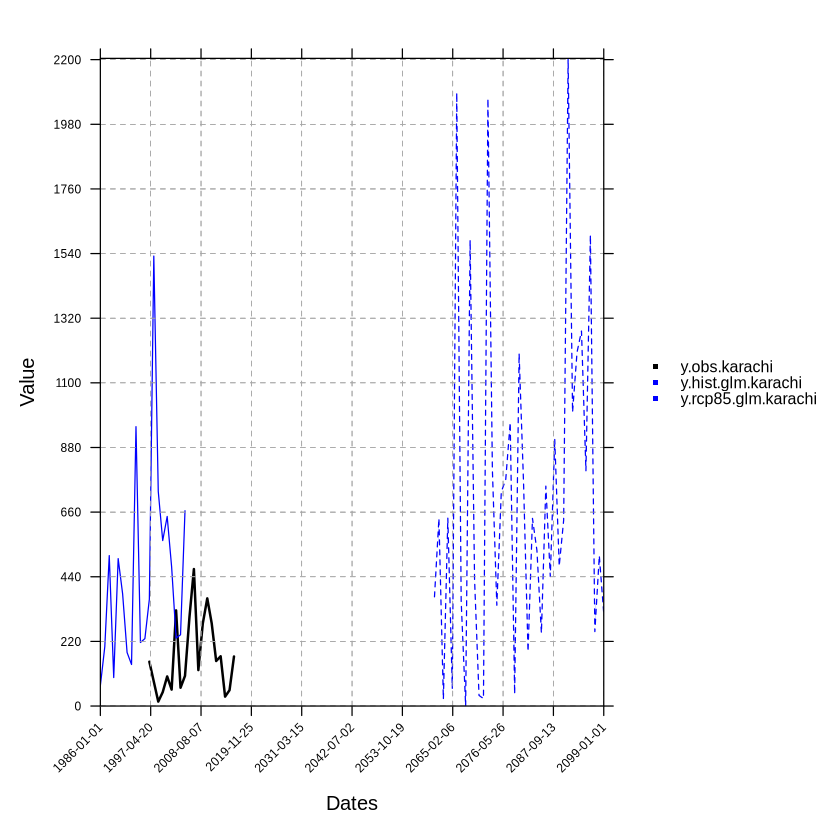

In [38]:
############################################################################
## local downscaled projections (time-series): Karachi airport and Murree ##
############################################################################

## karachi (airport) ##
lon.karachi = 67.133 
lat.karachi = 24.9

## yearly time series ##
y.obs.karachi = subsetGrid(aggregateGrid(y.obs, aggr.y = list(FUN = "sum")), 
                           lonLim = lon.karachi, latLim = lat.karachi)

y.hist.glm.karachi = subsetGrid(aggregateGrid(y.hist.glm, aggr.y = list(FUN = "sum", 
                                                                        na.rm = TRUE)), 
                                lonLim = lon.karachi, latLim = lat.karachi)
y.rcp85.glm.karachi = subsetGrid(aggregateGrid(y.rcp85.glm, aggr.y = list(FUN = "sum", 
                                                                          na.rm = TRUE)), 
                                 lonLim = lon.karachi, latLim = lat.karachi)

## plotting ##
temporalPlot(y.obs.karachi,
             y.hist.glm.karachi, y.rcp85.glm.karachi,
             cols = c("black", "blue", "blue"),
             lty = c(1, 1, 2),
             lwd = c(2, 1, 1))

[2026-07-17 18:54:43.234393] Performing annual aggregation...

[2026-07-17 18:54:43.239134] Done.

[2026-07-17 18:54:43.24852] Performing annual aggregation...

[2026-07-17 18:54:43.251605] Done.

[2026-07-17 18:54:43.266022] Performing annual aggregation...

[2026-07-17 18:54:43.271739] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



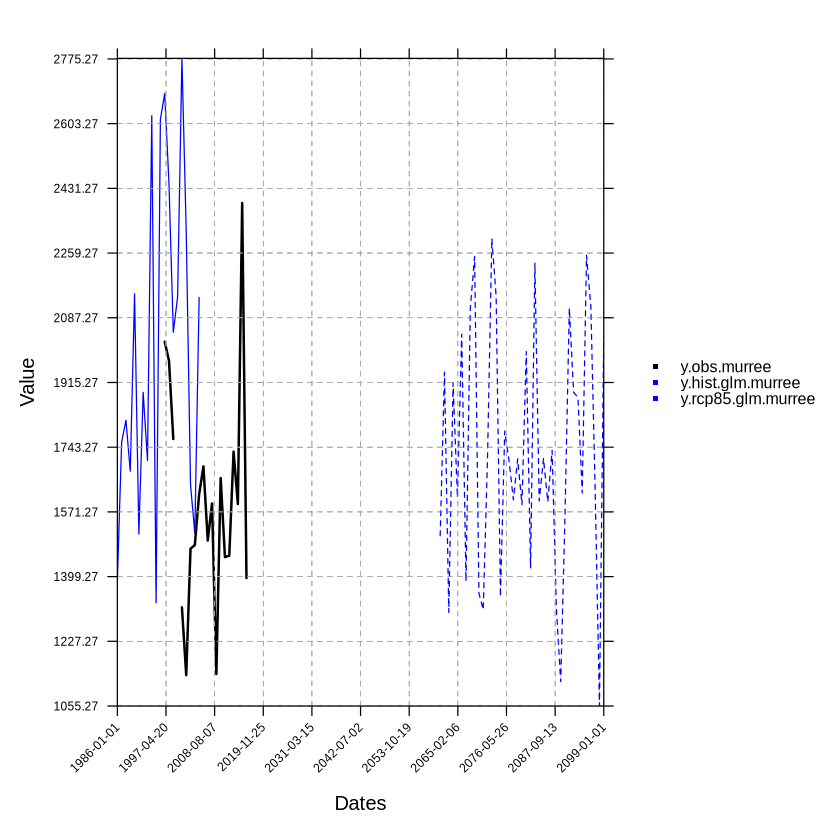

In [39]:
## murree ##
lon.murree = 73.383 
lat.murree = 33.917

## yearly time series ##
y.obs.murree = subsetGrid(aggregateGrid(y.obs, aggr.y = list(FUN = "sum")), 
                           lonLim = lon.murree, latLim = lat.murree)

y.hist.glm.murree = subsetGrid(aggregateGrid(y.hist.glm, aggr.y = list(FUN = "sum", 
                                                                        na.rm = TRUE)), 
                                lonLim = lon.murree, latLim = lat.murree)
y.rcp85.glm.murree = subsetGrid(aggregateGrid(y.rcp85.glm, aggr.y = list(FUN = "sum", 
                                                                          na.rm = TRUE)), 
                                 lonLim = lon.murree, latLim = lat.murree)

## plotting ##
temporalPlot(y.obs.murree,
             y.hist.glm.murree, y.rcp85.glm.murree,
             cols = c("black", "blue", "blue"),
             lty = c(1, 1, 2),
             lwd = c(2, 1, 1))

## 10. Further Exercises

This notebook has introduced the complete workflow for statistical downscaling, from the preparation of large-scale atmospheric predictors to the generation of local climate projections at meteorological stations. However, it can be easily extended in order to explore additional aspects of statistical downscaling and climate change.

Some possible extensions include:

* Compare additional GCMs. Repeat the downscaling procedure using the remaining CMIP5 models available in the dataset (CNRM-CM5 and MPI-ESM-MR). Compare the projected climate change signals among models and assess the uncertainty associated with the choice of driving GCM.
* Build a multi-model ensemble. Combine the downscaled projections from several GCMs to produce a Multi-Model Ensemble Mean (MMEM). Compare the ensemble projection with those obtained from the individual models and discuss the advantages of ensemble approaches.
* Experiment with different predictor combinations. Investigate how the selection of atmospheric predictors influences the performance of the statistical downscaling models. Are all five predictors equally important, or can similar results be obtained using a smaller subset?
* Evaluate additional validation metrics. Besides bias and correlation, compute other performance measures such as the Root Mean Square Error (RMSE), Mean Absolute Error (MAE), or the ratio of variances to obtain a more complete assessment of model skill.
* Rather than focusing only on climatological means, analyze climate indices from the downscaled projections such as ND35, NRD and R50. Compare the projected changes in these indices with the changes in mean temperature and precipitation, and discuss whether extremes evolve differently from the mean climate.
* Compare different emission scenarios (i.e. RCP4.5). Analyse how the projected climate change signals differ under alternative greenhouse gas pathways.
* Investigate regional differences. Extend the station-based analysis beyond Karachi and Murree by selecting stations located in different climatic regions of Pakistan. Compare how projected warming and precipitation changes vary between coastal, mountainous and arid environments.
* Assess the robustness of the downscaling methods. Compare the future projections obtained with the Analogs and regression-based approaches. Identify regions where both methods agree and locations where methodological uncertainty remains large.

These exercises illustrate that statistical downscaling is not simply a technical procedure for increasing spatial resolution. It is also a framework for evaluating uncertainty, comparing modelling strategies and translating coarse-resolution climate model projections into information that is directly relevant for local climate impact studies. Exploring these extensions will provide a deeper understanding of both the capabilities and the limitations of statistical downscaling for climate change applications.